In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import os
import zipfile
import glob
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold
print("Successful libraries import ✅")
import sklearn.model_selection 

Successful libraries import ✅


In [2]:
# Loading Data
soil = pd.read_csv("state_soil_data.csv")
crop = pd.read_csv("crop_yield.csv")
weather = pd.read_csv("state_weather_data_1997_2020.csv")

In [3]:
# Clean Column Names
for df in [soil, crop, weather]:
    df.columns = df.columns.str.strip().str.lower()# Clean Column Names
for df in [soil, crop, weather]:
    df.columns = df.columns.str.strip().str.lower()

In [4]:
# Clean Text Data
for df in [soil, crop, weather]:
    df['state'] = df['state'].str.strip().str.lower()

crop['season'] = crop['season'].str.strip().str.lower()
crop['crop'] = crop['crop'].str.strip().str.lower()

In [5]:
crop.describe()

,year,area,production,fertilizer,pesticide,yield
count,19689.000000,1.968900e+04,1.968900e+04,1.968900e+04,1.968900e+04,19689.000000
mean,2009.127584,1.799266e+05,1.643594e+07,2.410331e+07,4.884835e+04,79.954009
std,6.498099,7.328287e+05,2.630568e+08,9.494600e+07,2.132874e+05,878.306193
min,1997.000000,5.000000e-01,0.000000e+00,5.417000e+01,9.000000e-02,0.000000
25%,2004.000000,1.390000e+03,1.393000e+03,1.880146e+05,3.567000e+02,0.600000
50%,2010.000000,9.317000e+03,1.380400e+04,1.234957e+06,2.421900e+03,1.030000
75%,2015.000000,7.511200e+04,1.227180e+05,1.000385e+07,2.004170e+04,2.388889
max,2020.000000,5.080810e+07,6.326000e+09,4.835407e+09,1.575051e+07,21105.000000


In [6]:
print(soil.shape)

(30, 5)


In [7]:
print(crop.shape)

(19689, 9)


In [8]:
print(weather.shape)

(720, 5)


In [9]:
crop.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19689 entries, 0 to 19688
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   crop        19689 non-null  object 
 1   year        19689 non-null  int64  
 2   season      19689 non-null  object 
 3   state       19689 non-null  object 
 4   area        19689 non-null  float64
 5   production  19689 non-null  int64  
 6   fertilizer  19689 non-null  float64
 7   pesticide   19689 non-null  float64
 8   yield       19689 non-null  float64
dtypes: float64(4), int64(2), object(3)
memory usage: 1.4+ MB


In [10]:
# Filter ONLY MAIZE
maize_df = crop[crop['crop'] == 'maize']# Filter ONLY MAIZE
maize_df = crop[crop['crop'] == 'maize']

In [11]:
# Merge Datasets
# Merge weather
df = maize_df.merge(weather, on=['state', 'year'], how='left')
# Merge soil
df = df.merge(soil, on='state', how='left')

In [12]:
print(df.shape)

(975, 16)


In [13]:
# Handle Missing Values
(df.isnull().mean()*100)

crop                    0.0
year                    0.0
season                  0.0
state                   0.0
area                    0.0
production              0.0
fertilizer              0.0
pesticide               0.0
yield                   0.0
avg_temp_c              0.0
total_rainfall_mm       0.0
avg_humidity_percent    0.0
n                       0.0
p                       0.0
k                       0.0
ph                      0.0
dtype: float64

In [14]:
print(df.head(10))

    crop  year      season        state      area  production   fertilizer  \
0  maize  1997      kharif        assam   19216.0       14721   1828786.72   
1  maize  1997      kharif    karnataka  502797.0     1391132  47851190.49   
2  maize  1997        rabi    karnataka   48844.0       98932   4648483.48   
3  maize  1997      summer    karnataka    9730.0       20893    926004.10   
4  maize  1997      kharif    meghalaya   17175.0       24878   1634544.75   
5  maize  1997  whole year  west bengal   35469.0      130390   3375584.73   
6  maize  1998      kharif        assam   19810.0       13965   1957228.00   
7  maize  1998      kharif    karnataka  450472.0     1542607  44506633.60   
8  maize  1998        rabi    karnataka   49922.0      101605   4932293.60   
9  maize  1998      summer    karnataka   11974.0       27080   1183031.20   

   pesticide     yield  avg_temp_c  total_rainfall_mm  avg_humidity_percent  \
0    5956.96  0.615652       22.41            1468.92         

In [15]:
# Count total duplicate rows
df.duplicated().sum()

np.int64(0)

In [16]:
# Drop Unnecessary Columns to avoid data leakage)
df = df.drop(columns=['crop', 'production','area'])

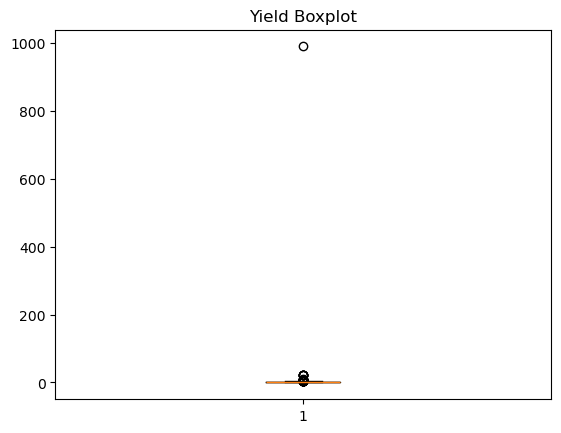

In [17]:
# checking outliers
import matplotlib.pyplot as plt

plt.boxplot(df['yield'])
plt.title("Yield Boxplot")
plt.show()

In [18]:
# OUTLIER REMOVAL
def remove_outliers(df):
    numeric_cols = df.select_dtypes(include=np.number).columns
    
    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower = Q1 - 2.5 * IQR
        upper = Q3 + 2.5 * IQR
        
        df = df[(df[col] >= lower) & (df[col] <= upper)]
    
    return df

df = remove_outliers(df)

In [19]:
print(df.shape)

(778, 13)


In [20]:
# Feature Engineering
import pandas as pd
import numpy as np

# FEATURE ENGINEERING
# -----------------------------

# Soil fertility index
df["soil_fertility"] = (df["n"] + df["p"] + df["k"]) / 3

# Rainfall categories
df["rainfall_cat"] = pd.cut(
    df["total_rainfall_mm"],
    bins=[-np.inf, 500, 1500, np.inf],
    labels=[0, 1, 2]
).astype(int)

# Temperature categories
df["temp_cat"] = pd.cut(
    df["avg_temp_c"],
    bins=[-np.inf, 20, 30, np.inf],
    labels=[0, 1, 2]
).astype(int)

# Interaction features
df["rain_temp_interaction"] = df["total_rainfall_mm"] * df["avg_temp_c"]
df["fert_ph_interaction"] = df["fertilizer"] * df["ph"]
df["nitrogen_rain_interaction"] = df["n"] * df["total_rainfall_mm"]

# Log transforms
df["rainfall_log"] = np.log1p(df["total_rainfall_mm"])
df["fertilizer_log"] = np.log1p(df["fertilizer"])

print("Feature engineering done!")


Feature engineering done!


In [21]:
# Encode Categorical Data
df = pd.get_dummies(df, columns=['state', 'season'], drop_first=True)

In [22]:
# Correlation Analysis
corr_matrix = df.corr()

corr_target = corr_matrix['yield'].sort_values(ascending=False)

print(corr_target)

yield                        1.000000
p                            0.321626
year                         0.297807
season_rabi                  0.284348
fertilizer                   0.261836
fert_ph_interaction          0.249101
state_bihar                  0.248062
pesticide                    0.246355
state_telangana              0.221303
avg_temp_c                   0.220945
state_west bengal            0.215420
fertilizer_log               0.206825
soil_fertility               0.201100
state_karnataka              0.186672
ph                           0.180349
n                            0.166073
temp_cat                     0.162860
state_tamil nadu             0.157498
state_delhi                  0.082207
season_summer                0.074419
season_whole year            0.062959
state_madhya pradesh         0.050934
state_himachal pradesh       0.033383
state_manipur                0.033159
state_uttar pradesh          0.003410
avg_humidity_percent        -0.035262
state_kerala

In [23]:
# Remove Low Correlation Features
low_corr = corr_target[abs(corr_target) < 0.05].index
df = df.drop(columns=low_corr)

In [24]:
# Variance Threshold
from sklearn.feature_selection import VarianceThreshold

X = df.drop(columns=['yield'])
y = df['yield']

selector = VarianceThreshold(threshold=0.01)
X_var = selector.fit_transform(X)

selected_cols = X.columns[selector.get_support()]
X = pd.DataFrame(X_var, columns=selected_cols)

In [25]:
# Train/Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [26]:
# Train Model
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [27]:
# Evaluate Model
from sklearn.metrics import mean_squared_error

preds = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, preds))
print("RMSE:", rmse)

RMSE: 0.422087762615838


In [28]:
import numpy as np
from sklearn.metrics import mean_squared_error

baseline = np.mean(y_train)
baseline_preds = np.full_like(y_test, baseline)

rmse_baseline = np.sqrt(mean_squared_error(y_test, baseline_preds))
print("Baseline RMSE:", rmse_baseline)

Baseline RMSE: 0.9155175033590371


In [29]:
# Gradient Boosting Regressor
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train, y_train)

gb_preds = gb_model.predict(X_test)

In [30]:
# Evaluate Model
from sklearn.metrics import mean_squared_error
import numpy as np

rmse_gb = np.sqrt(mean_squared_error(y_test, gb_preds))
print("GB RMSE:", rmse_gb)

GB RMSE: 0.4533802062653822


In [31]:
# XGBoost Regressor
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)

In [32]:
# Evaluate:
rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_preds))
print("XGB RMSE:", rmse_xgb)

XGB RMSE: 0.42209339695873127


In [33]:
# LightGBM Regressor
from lightgbm import LGBMRegressor

lgb_model = LGBMRegressor(random_state=42)

lgb_model.fit(X_train, y_train)

lgb_preds = lgb_model.predict(X_test)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001149 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1994
[LightGBM] [Info] Number of data points in the train set: 622, number of used features: 31
[LightGBM] [Info] Start training from score 2.139673
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive ga

In [34]:
# Evaluate:
rmse_lgb = np.sqrt(mean_squared_error(y_test, lgb_preds))
print("LGB RMSE:", rmse_lgb)

LGB RMSE: 0.4021636566711856


In [35]:
# comparison table
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Compute RMSE and R² for each model
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_preds))

rf_rmse = np.sqrt(mean_squared_error(y_test, preds))
rf_r2 = r2_score(y_test, preds)

gb_rmse = np.sqrt(mean_squared_error(y_test, gb_preds))
gb_r2 = r2_score(y_test, gb_preds)

xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
xgb_r2 = r2_score(y_test, xgb_preds)

lgb_rmse = np.sqrt(mean_squared_error(y_test, lgb_preds))
lgb_r2 = r2_score(y_test, lgb_preds)

# Build comparison table
results = {
    "Baseline": {"RMSE": baseline_rmse, "R²": None},
    "RandomForest": {"RMSE": rf_rmse, "R²": rf_r2},
    "GradientBoosting": {"RMSE": gb_rmse, "R²": gb_r2},
    "XGBoost": {"RMSE": xgb_rmse, "R²": xgb_r2},
    "LightGBM": {"RMSE": lgb_rmse, "R²": lgb_r2}
}

results_df = pd.DataFrame(results).T
print(results_df)



                      RMSE        R²
Baseline          0.915518       NaN
RandomForest      0.422088  0.787286
GradientBoosting  0.453380  0.754576
XGBoost           0.422093  0.787280
LightGBM          0.402164  0.806894


In [36]:
# Use the regularized version
model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=5,
    num_leaves=31,
    min_child_samples=30,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42
)

In [37]:
# Re-evaluate properly
# Train
model.fit(X_train, y_train)

# Predictions
train_preds = model.predict(X_train)
test_preds = model.predict(X_test)

# RMSE
print("Train RMSE:", np.sqrt(mean_squared_error(y_train, train_preds)))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, test_preds)))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.016875 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1990
[LightGBM] [Info] Number of data points in the train set: 622, number of used features: 29
[LightGBM] [Info] Start training from score 2.139673
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive ga

In [38]:
# Cross-Validation
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import make_scorer, mean_squared_error, r2_score
import numpy as np

# Define scoring functions
rmse_scorer = make_scorer(
    lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)),
    greater_is_better=False
)

r2_scorer = make_scorer(r2_score)

# Set up KFold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Run CV for LightGBM (replace with your model variable)
rmse_scores = cross_val_score(model, X, y, cv=kf, scoring=rmse_scorer)
r2_scores = cross_val_score(model, X, y, cv=kf, scoring=r2_scorer)

print("CV RMSE scores:", -rmse_scores)  # negate because scorer returns negative
print("Mean CV RMSE:", -rmse_scores.mean())
print("CV R² scores:", r2_scores)
print("Mean CV R²:", r2_scores.mean())


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000436 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1990
[LightGBM] [Info] Number of data points in the train set: 622, number of used features: 29
[LightGBM] [Info] Start training from score 2.139673
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive ga

In [39]:
# hyperparameter tuning This will help reduce variance and improve stability across folds
from lightgbm import LGBMRegressor
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.metrics import make_scorer, mean_squared_error, r2_score
import numpy as np

# Define scoring functions
rmse_scorer = make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)), greater_is_better=False)
r2_scorer = make_scorer(r2_score)

# Parameter grid for tuning
param_grid = {
    'n_estimators': [200, 300, 500],
    'learning_rate': [0.01, 0.03, 0.05],
    'max_depth': [3, 5, 7],
    'num_leaves': [15, 31, 63],
    'min_child_samples': [20, 30, 50],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'reg_alpha': [0.0, 0.1, 0.5],
    'reg_lambda': [0.0, 0.1, 0.5]
}

# Base model
lgbm = LGBMRegressor(random_state=42)

# Cross-validation setup
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Randomized search
search = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_grid,
    n_iter=30,              # number of random combinations to try
    scoring={'RMSE': rmse_scorer, 'R2': r2_scorer},
    refit='RMSE',           # refit using RMSE
    cv=kf,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Run search
search.fit(X, y)

print("Best Parameters:", search.best_params_)
print("Best CV RMSE:", -search.best_score_)


Fitting 5 folds for each of 30 candidates, totalling 150 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000235 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2386
[LightGBM] [Info] Number of data points in the train set: 778, number of used features: 29
[LightGBM] [Info] Start training from score 2.144691
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Lig

In [40]:
# Retrain with best parameters
best_model = LGBMRegressor(
    subsample=1.0,
    reg_lambda=0.5,
    reg_alpha=0.1,
    num_leaves=31,
    n_estimators=500,
    min_child_samples=20,
    max_depth=5,
    learning_rate=0.05,
    colsample_bytree=1.0,
    random_state=42
)

best_model.fit(X_train, y_train)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.022435 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1994
[LightGBM] [Info] Number of data points in the train set: 622, number of used features: 31
[LightGBM] [Info] Start training from score 2.139673
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive ga

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,5
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [41]:
# Evaluate again  
train_preds = best_model.predict(X_train)
test_preds = best_model.predict(X_test)

print("Train RMSE:", np.sqrt(mean_squared_error(y_train, train_preds)))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, test_preds)))
print("Train R²:", r2_score(y_train, train_preds))
print("Test R²:", r2_score(y_test, test_preds))


Train RMSE: 0.22159545312212434
Test RMSE: 0.4241375260747563
Train R²: 0.9535261655881607
Test R²: 0.7852146545606082


In [42]:
# training tuned LightGBM on the full dataset (X, y)
from lightgbm import LGBMRegressor
import joblib

# Final model with best parameters
final_model = LGBMRegressor(
    subsample=1.0,
    reg_lambda=0.5,
    reg_alpha=0.1,
    num_leaves=31,
    n_estimators=500,
    min_child_samples=20,
    max_depth=5,
    learning_rate=0.05,
    colsample_bytree=1.0,
    random_state=42
)

# Train on the full dataset (X, y)
final_model.fit(X, y)

# Save the model for deployment
joblib.dump(final_model, "lightgbm_final.pkl")

print("Final model trained on full dataset and saved as lightgbm_final.pkl")


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.309293 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2400
[LightGBM] [Info] Number of data points in the train set: 778, number of used features: 36
[LightGBM] [Info] Start training from score 2.144691
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive ga

In [43]:
# saving final model 
import joblib
joblib.dump(final_model, "lightgbm_final.pkl")


['lightgbm_final.pkl']

In [44]:
#confirm it works
import joblib

# Load the saved model
model = joblib.load("lightgbm_final.pkl")
print("Model loaded successfully")


Model loaded successfully


In [45]:
import joblib

model = joblib.load("lightgbm_final.pkl")
print(model.feature_name_)

['year', 'fertilizer', 'pesticide', 'avg_temp_c', 'total_rainfall_mm', 'n', 'p', 'k', 'ph', 'soil_fertility', 'rainfall_cat', 'temp_cat', 'rain_temp_interaction', 'fert_ph_interaction', 'nitrogen_rain_interaction', 'rainfall_log', 'fertilizer_log', 'state_arunachal_pradesh', 'state_assam', 'state_bihar', 'state_chhattisgarh', 'state_delhi', 'state_gujarat', 'state_haryana', 'state_jharkhand', 'state_karnataka', 'state_maharashtra', 'state_meghalaya', 'state_mizoram', 'state_nagaland', 'state_odisha', 'state_tamil_nadu', 'state_tripura', 'state_uttarakhand', 'state_west_bengal', 'season_kharif', 'season_rabi', 'season_summer', 'season_whole_year', 'season_winter']


In [46]:
df.to_csv("clean_crop_data.csv", index=False)

In [47]:
df.head()

,year,fertilizer,pesticide,yield,avg_temp_c,total_rainfall_mm,n,p,k,ph,...,state_tamil nadu,state_telangana,state_tripura,state_uttarakhand,state_west bengal,season_kharif,season_rabi,season_summer,season_whole year,season_winter
0,1997,1828786.72,5956.96,0.615652,22.41,1468.92,60,18,38,5.8,...,False,False,False,False,False,True,False,False,False,False
2,1997,4648483.48,15141.64,1.980000,23.55,894.16,72,42,25,6.9,...,False,False,False,False,False,False,True,False,False,False
3,1997,926004.10,3016.30,2.165714,23.55,894.16,72,42,25,6.9,...,False,False,False,False,False,False,False,True,False,False
4,1997,1634544.75,5324.25,1.444286,17.16,1954.46,52,16,33,5.6,...,False,False,False,False,False,True,False,False,False,False
5,1997,3375584.73,10995.39,2.658462,25.85,1564.19,85,40,45,6.2,...,False,False,False,False,True,False,False,False,True,False


In [48]:
# Moving from a wide, binary dataset to a tidy, feature‑rich dataset that is better for both visualization (Power BI) and prediction (LightGBM).
# CLEAN COLUMN NAMES (IMPORTANT)

df.columns = df.columns.str.strip().str.replace(' ', '_')

# FIX SEASON (One-hot → single column)

season_cols = [col for col in df.columns if col.startswith('season_')]

if season_cols:
    df['season'] = df[season_cols].idxmax(axis=1)
    df['season'] = (
        df['season']
        .str.replace('season_', '', regex=False)
        .str.replace('_', ' ')
        .str.title()
    )
    df.drop(columns=season_cols, inplace=True)


# FIX STATE (One-hot → single column)

state_cols = [col for col in df.columns if col.startswith('state_')]

if state_cols:
    df['state'] = df[state_cols].idxmax(axis=1)
    df['state'] = (
        df['state']
        .str.replace('state_', '', regex=False)
        .str.replace('_', ' ')
        .str.title()
    )
    df.drop(columns=state_cols, inplace=True)


# REORDER COLUMNS (clean look)
# -----------------------------
cols_order = ['year', 'state', 'season', 'fertilizer', 'pesticide', 'predicted_yield']
existing_cols = [col for col in cols_order if col in df.columns]

df = df[existing_cols + [col for col in df.columns if col not in existing_cols]]


# SAVE CLEAN FILE

df.to_excel("Clean_Predicted_yield.xlsx", index=False)

print("✅ Clean Excel saved as clean_predicted_yield.xlsx")

✅ Clean Excel saved as clean_predicted_yield.xlsx


In [49]:
df.head()

,year,state,season,fertilizer,pesticide,yield,avg_temp_c,total_rainfall_mm,n,p,k,ph,soil_fertility,rainfall_cat,temp_cat,rain_temp_interaction,fert_ph_interaction,nitrogen_rain_interaction,rainfall_log,fertilizer_log
0,1997,Assam,Kharif,1828786.72,5956.96,0.615652,22.41,1468.92,60,18,38,5.8,38.666667,1,1,32918.4972,1.060696e+07,88135.20,7.292963,14.419164
2,1997,Karnataka,Rabi,4648483.48,15141.64,1.980000,23.55,894.16,72,42,25,6.9,46.333333,1,1,21057.4680,3.207454e+07,64379.52,6.797002,15.352052
3,1997,Karnataka,Summer,926004.10,3016.30,2.165714,23.55,894.16,72,42,25,6.9,46.333333,1,1,21057.4680,6.389428e+06,64379.52,6.797002,13.738635
4,1997,Meghalaya,Kharif,1634544.75,5324.25,1.444286,17.16,1954.46,52,16,33,5.6,33.666667,2,0,33538.5336,9.153451e+06,101631.92,7.578381,14.306875
5,1997,West Bengal,Whole Year,3375584.73,10995.39,2.658462,25.85,1564.19,85,40,45,6.2,56.666667,2,1,40434.3115,2.092863e+07,132956.15,7.355763,15.032079
